In [62]:
import torch
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
from models import Emotion_Models
from tqdm import tqdm
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, classification_report
from torch import optim
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

In [63]:
from config import Config as cf
from datasets import Emotions_Dataset, show_single_img, show_batch_dataset
import cv2

In [64]:
print(cf.DEVICE)

cuda


In [65]:
transform_train = A.Compose([
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.6),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.CoarseDropout(
        num_holes_range= (1, 5), 
        p=0.5
    ), 
    A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255),
    ToTensorV2(), 
])

transform_test = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255),
    ToTensorV2(), 
])



c:\Users\sanng\miniconda3\envs\vision_env\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [66]:
dataset_train = Emotions_Dataset(cf.TRAIN_PATH, transform= transform_train)
dataset_test = Emotions_Dataset(cf.TEST_PATH, transform = transform_test)

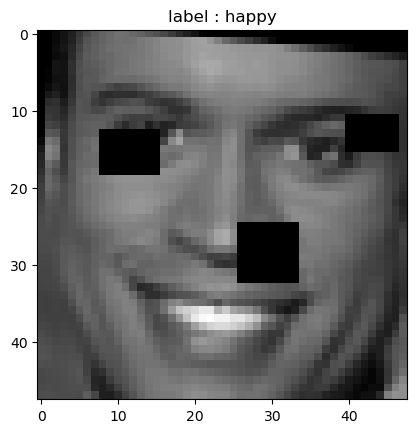

In [67]:
dataset_train_item = dataset_train[random.randint(0,len(dataset_train))]
show_single_img(dataset_train_item)

In [68]:
def sampler_init(dataset : Emotions_Dataset):
    weight = [1/dataset.len_class[i[1]] for i in dataset.sample]
    sampler = WeightedRandomSampler(
        weights= weight,
        num_samples= len(dataset),
        replacement= True
    )
    return sampler

In [69]:
train_loader = DataLoader(
    dataset= dataset_train,
    batch_size= 128,
    sampler= sampler_init(dataset_train),
    pin_memory= True,
    drop_last= True,
    num_workers= 8,
    prefetch_factor= 4,
    persistent_workers=True

)


test_loader = DataLoader(
    dataset= dataset_test,
    batch_size=128,
    sampler=sampler_init(dataset_test),
    pin_memory= True,
    drop_last= False
)

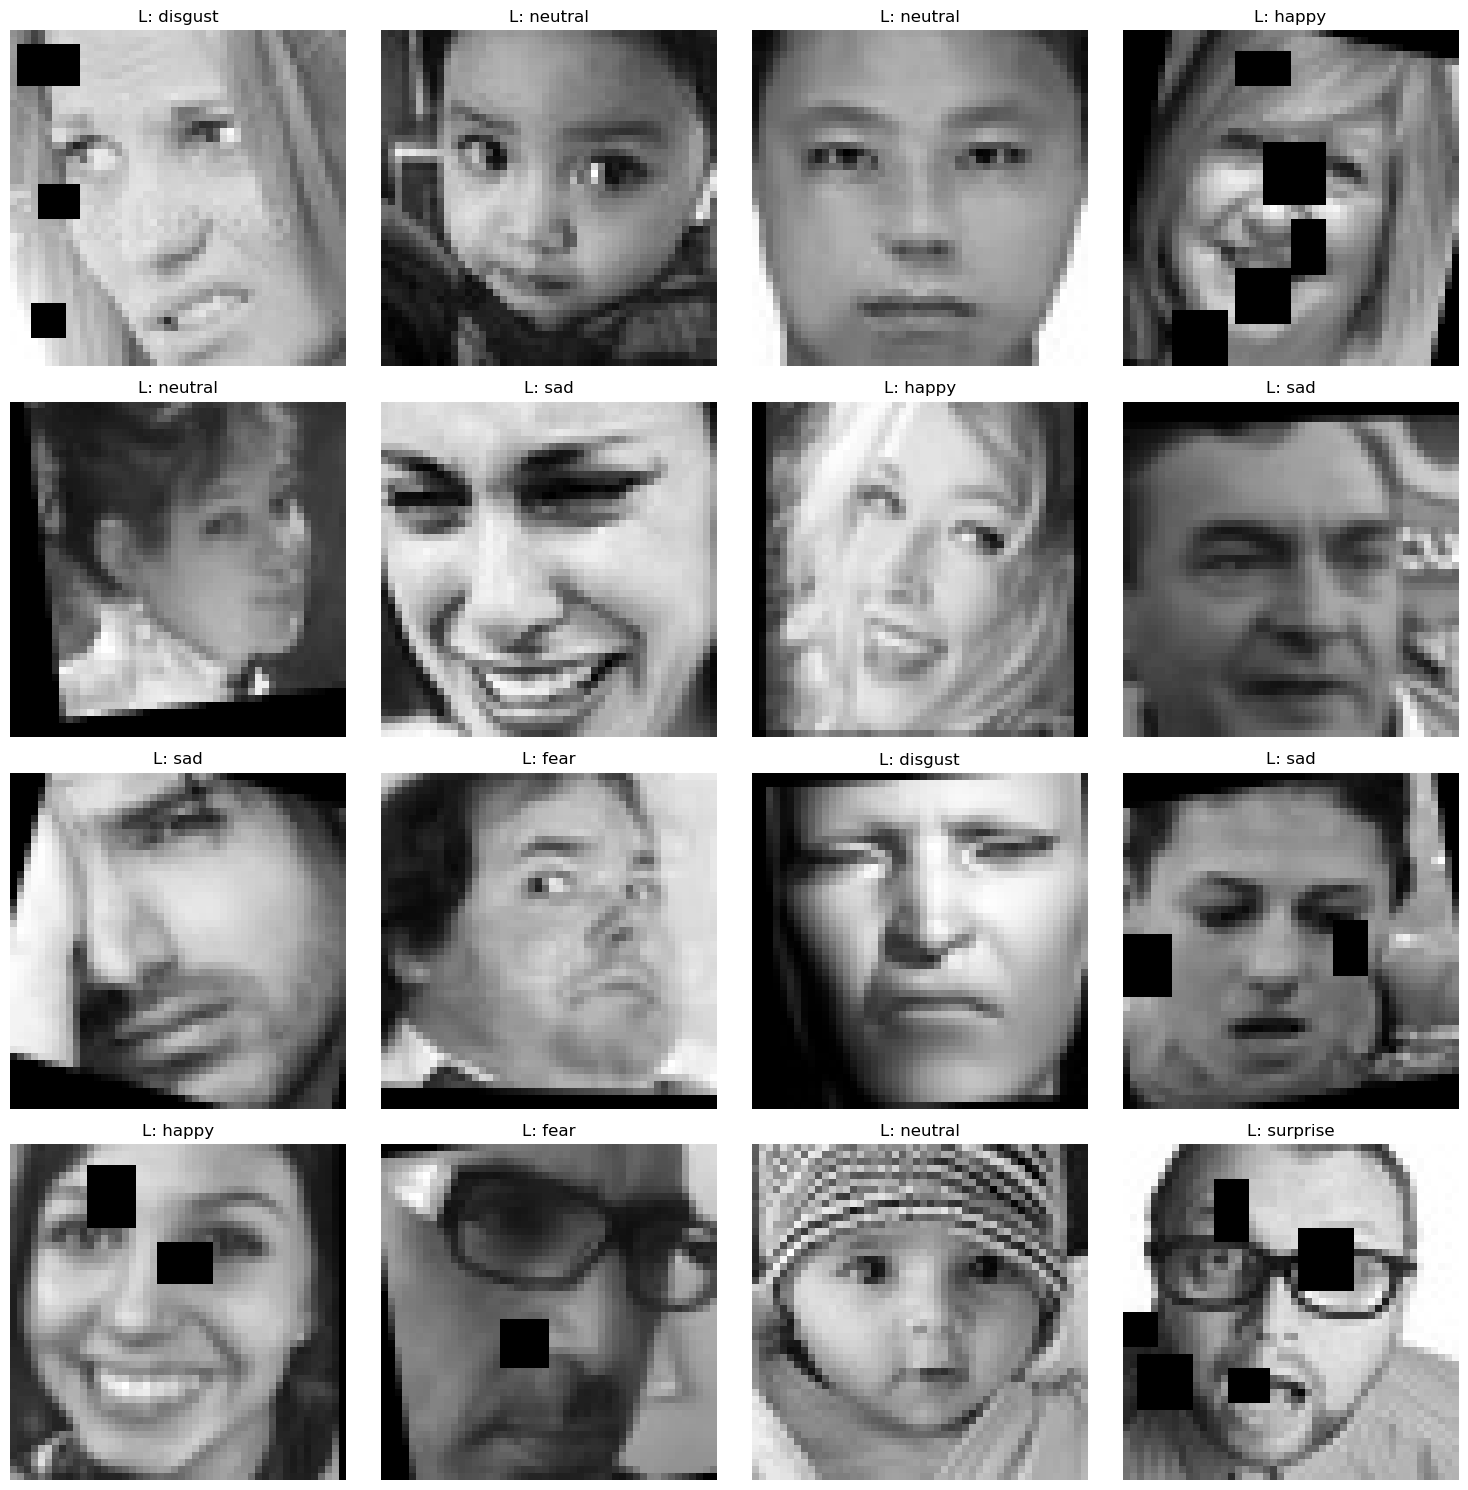

In [70]:
show_batch_dataset(train_loader)

In [71]:
model = Emotion_Models(classes= 7)
# model.save_model()
model.load_model(device= cf.DEVICE)
# model = model.to(config.DEVICE)

In [72]:
def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    accuracy = accuracy_score(all_labels, all_preds)

    return precision, recall, f1, accuracy

In [73]:
def training_models(device, model, train_loader, test_loader, num_epochs=50, compile_model=False):

    model = model.to(device)

    if compile_model and hasattr(torch, "compile"):
        model = torch.compile(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.OneCycleLR(
            optimizer, 
            max_lr=1e-3, 
            steps_per_epoch=len(train_loader), 
            epochs=num_epochs,
            pct_start=0.1
        )

    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'test_f1': [],
        'lr' : [],
        'precision' : [],
        'recall' : []
    }

    best_f1 = 0.0

    for epoch in range(num_epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for batch_idx, (inputs, labels) in enumerate(pbar):

            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            scaler.step(optimizer)
            scaler.update()

            scheduler.step()

            running_loss += loss.detach().item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.6f}")

        
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        precision, recall, f1, accuracy = evaluate(model, test_loader, device)

        current_lr = scheduler.get_last_lr()[0] 

        print(
            f"Epoch {epoch+1} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Test Acc: {accuracy:.4f} | "
            f"F1: {f1:.4f} | "
            f"LR: {current_lr:.6f}"
        )

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(accuracy)
        history['test_f1'].append(f1)
        history['precision'].append(precision)
        history['recall'].append(recall)
        history['lr'].append(current_lr) 

        if f1 > best_f1:
            print("New Best Model Saved")
            best_f1 = f1
            model.save_model(path= 'models/best_model.pth')

    return history

In [74]:
history = training_models(
    device= cf.DEVICE, 
    model= model, 
    train_loader= train_loader, 
    test_loader= test_loader, 
    num_epochs=60
    )

Epoch 1/60: 100%|██████████| 224/224 [00:54<00:00,  4.10it/s, loss=1.7963, lr=0.000104]


Epoch 1 | Train Loss: 1.9286 | Train Acc: 0.2126 | Test Acc: 0.2531 | F1: 0.2066 | LR: 0.000104
New Best Model Saved


Epoch 2/60: 100%|██████████| 224/224 [00:54<00:00,  4.14it/s, loss=1.6531, lr=0.000280]


Epoch 2 | Train Loss: 1.7066 | Train Acc: 0.3645 | Test Acc: 0.3621 | F1: 0.3341 | LR: 0.000280
New Best Model Saved


Epoch 3/60: 100%|██████████| 224/224 [00:53<00:00,  4.15it/s, loss=1.5008, lr=0.000521]


...

Epoch 58 | Train Loss: 0.6033 | Train Acc: 0.9458 | Test Acc: 0.6874 | F1: 0.6894 | LR: 0.000003


Epoch 59/60: 100%|██████████| 224/224 [00:51<00:00,  4.39it/s, loss=0.5936, lr=0.000001]


Epoch 59 | Train Loss: 0.6077 | Train Acc: 0.9439 | Test Acc: 0.6960 | F1: 0.7001 | LR: 0.000001


Epoch 60/60: 100%|██████████| 224/224 [00:50<00:00,  4.39it/s, loss=0.5842, lr=0.000000]


Epoch 60 | Train Loss: 0.6068 | Train Acc: 0.9436 | Test Acc: 0.6914 | F1: 0.6953 | LR: 0.000000


In [ ]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(18, 12))

    plt.subplot(2, 2, 1)
    plt.plot(epochs, history['train_loss'], 'r-o', label='Train Loss', markersize=4)
    plt.title('Training Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(epochs, history['train_acc'], 'g-o', label='Train Acc', markersize=4)
    plt.plot(epochs, history['test_acc'], 'b-s', label='Test Acc', markersize=4)
    plt.title('Training & Test Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(epochs, history['test_f1'], 'm-v', label='F1-Score')
    plt.plot(epochs, history['precision'], 'c-x', label='Precision')
    plt.plot(epochs, history['recall'], 'y-d', label='Recall')
    plt.title('Detailed Metrics (Test Set)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(epochs, history['lr'], 'k-', label='Learning Rate')
    plt.title('Learning Rate Schedule (OneCycleLR)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('LR Value')
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout() 
    plt.show()

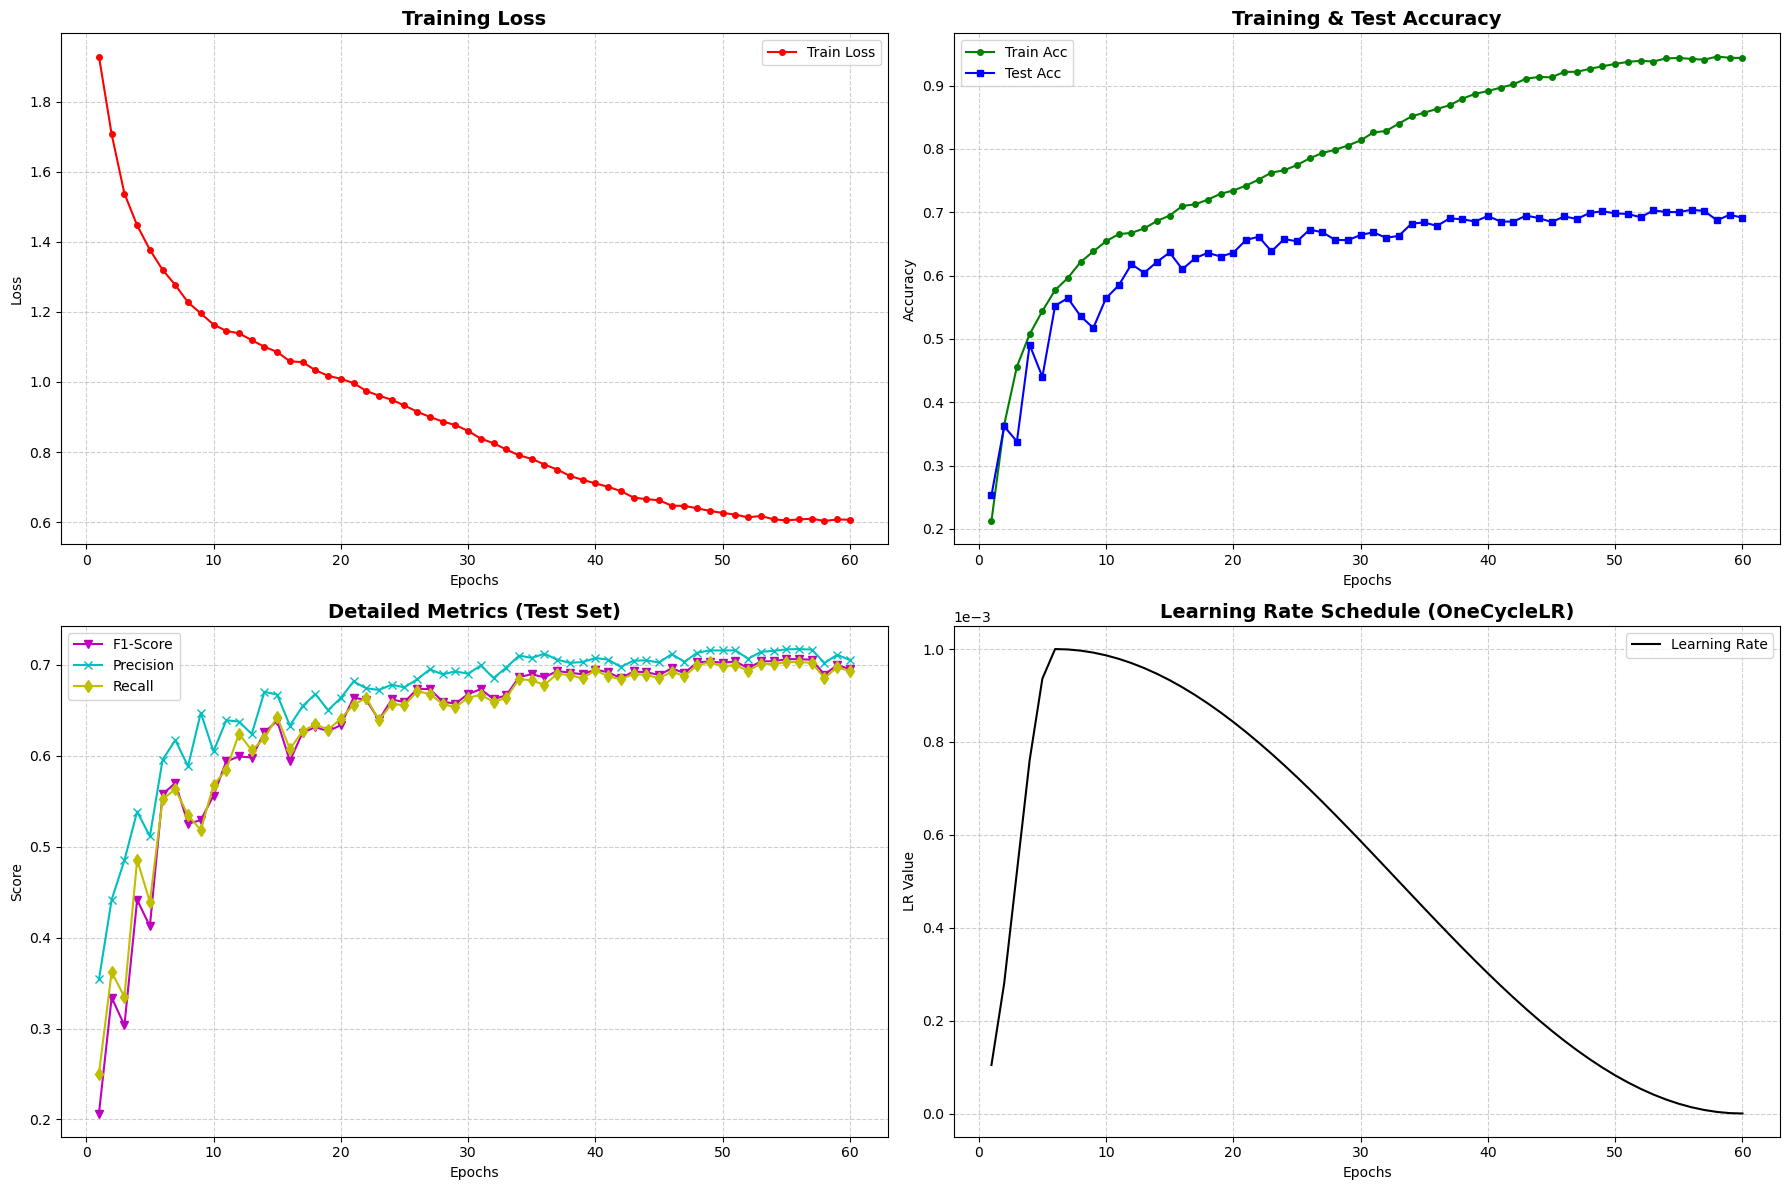

In [76]:
plot_history(history)

In [77]:
def plot_confusion_matrix(model, test_loader, device, classes_name):
    model.to(device)
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    

    print("BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):\n")
    print(classification_report(all_labels, all_preds, target_names=classes_name))


    cm = confusion_matrix(all_labels, all_preds)
    

    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=classes_name, yticklabels=classes_name)
    
    plt.title('Confusion Matrix (Unit: %)', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()

In [78]:
model = Emotion_Models(classes= 7)
model.load_model(path = 'models\\best_model.pth')

BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):

              precision    recall  f1-score   support

       angry       0.58      0.64      0.61      1014
     disgust       0.97      0.71      0.82      1013
        fear       0.60      0.55      0.57      1022
       happy       0.84      0.86      0.85      1081
     neutral       0.64      0.72      0.68       994
         sad       0.53      0.59      0.56       976
    surprise       0.87      0.85      0.86      1078

    accuracy                           0.71      7178
   macro avg       0.72      0.70      0.71      7178
weighted avg       0.72      0.71      0.71      7178



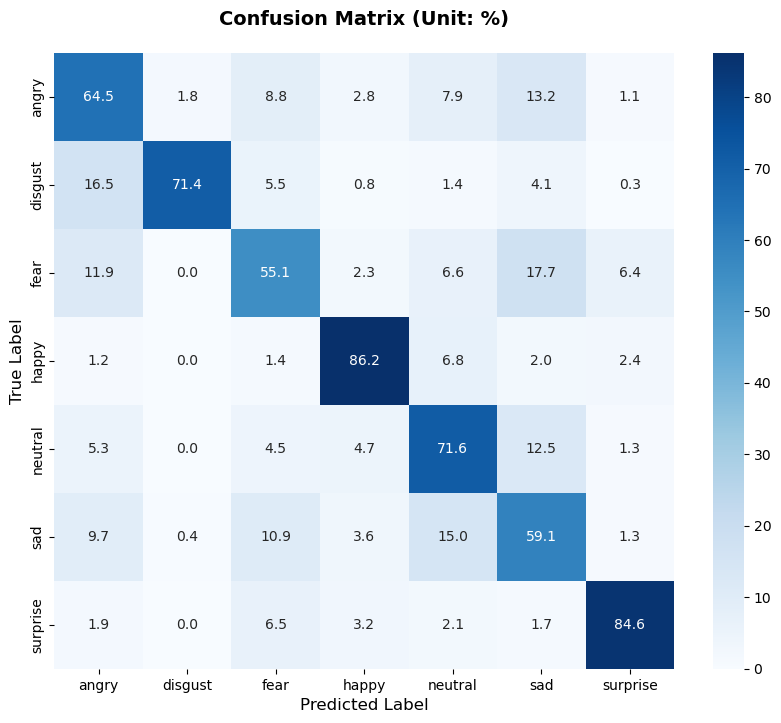

In [81]:
plot_confusion_matrix(model, test_loader,device= cf.DEVICE, classes_name = cf.CLASSES)